# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina 
- _Student No._: 2024-09224
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Problem 1: (Newman 6.7) Resistor Ladder

![Line Graph of Voltage Distribution Across 6 Internal](./Figures/e5_figure1.png)

*Figure 1: Line Graph of Voltage Distribution Across 6 Internal Junctions*

The resistor ladder was first solved for $N=6$ using a full matrix and `np.linalg.solve()`, which directly solves the system of linear equations. The resulting voltage distribution decreases from the first two nodes, which are connected to the 5 V source, toward the later nodes of the ladder. The calculated voltages remain within the expected range of 0 V to 5 V, showing how the applied voltage is distributed across the resistor network.

![Voltage Distribution Line Graphs for Different Numbers of Nodes](./Figures/e5_figure3.png)

*Figure 2: Voltage Distribution Line Graphs for Different Numbers of Nodes*

For larger systems, the resistor ladder was solved using a banded matrix representation and `bd.banded()`. Since the matrix is pentadiagonal, only its five nonzero diagonals need to be stored, making the method more memory-efficient than constructing a full $N \times N$ matrix. Figure 2 compares the voltage distributions for $N=10$, $100$, $1000$, $3000$, $5000$, $8000$, and $10{,}000$. As the number of nodes increases, the voltage drop becomes more gradual and is distributed across a greater number of nodes. For smaller values of $N$, the voltage decreases more rapidly over fewer nodes, while for $N=10{,}000$, the voltage distribution extends smoothly across the longer resistor ladder. The similar overall behavior across the different values of $N$ demonstrates that the banded-matrix approach can efficiently handle increasingly large resistor networks while maintaining the expected voltage distribution.


### Other comments
- It was nice figuring out how to code the matrices and learning how banded.py works. 


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

![reschain](./Figures/reschain.png)

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import banded as bd

In [12]:
# 3. N = 6

N = 6

# Construct matrix A
A = np.zeros((N,N))

for i in range(N):

    # Main Diagonal
    if i == 0 or i == N-1:
        A[i, i] = 3
    else:
        A[i, i] = 4

    # First off-diagonals
    if i-1 >= 0:
        A[i, i-1] = -1

    if i+1 < N:
        A[i, i+1] = -1

    # Second off-diagonals
    if i-2 >= 0:
        A[i, i-2] = -1

    if i+2 < N:
        A[i, i+2] = -1

# Construct matrix w
w = np.zeros(N)
w[0] = 5
w[1] = 5

# Solve Av = w
V = np.linalg.solve(A,w)

print("A =")
print(A)

print("\nw =")
print(w)

print("\nVoltages:")
for i in range(N):
    print(f"V{i+1} = {V[i]:.6f} V")

A =
[[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]

w =
[5. 5. 0. 0. 0. 0.]

Voltages:
V1 = 3.725490 V
V2 = 3.431373 V
V3 = 2.745098 V
V4 = 2.254902 V
V5 = 1.568627 V
V6 = 1.274510 V


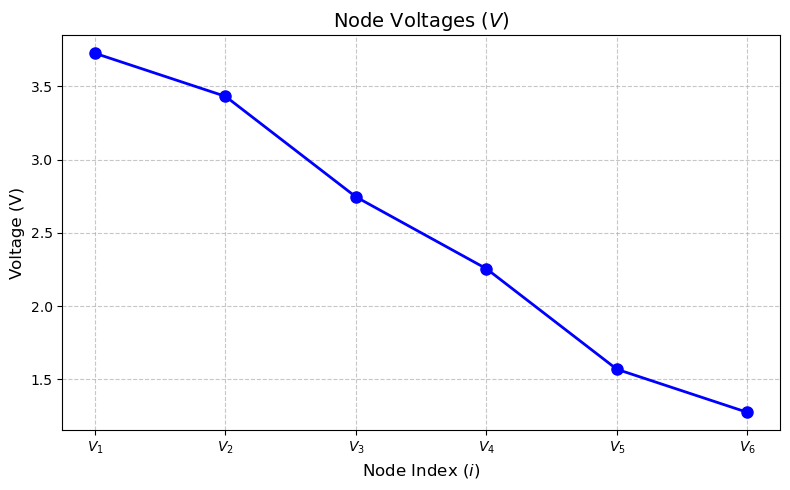

In [14]:
# Generate node numbers
nodes = np.arange(1, N + 1)

plt.figure(figsize=(8, 5))

# Plot voltage at each node
plt.plot(nodes, V, marker="o", linestyle="-", color="b", linewidth=2, markersize=8)

# Labeling and formatting
plt.title("Node Voltages ($V$)", fontsize=14)
plt.xlabel("Node Index ($i$)", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.xticks(nodes, [f"$V_{{{i}}}$" for i in nodes])
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [3]:
# 4. N = 10 000

N = 10000

# Create the banded matrix
# 5 = 2 upper diagonals + main diagonal + 2 lower diagonals
A_bd = np.zeros((5, N))

# Main diagonal
A_bd[2, :] = 4
A_bd[2, 0] = 3
A_bd[2, N-1] = 3

# First upper diagonal
A_bd[1, 1:] = -1

# Second upper diagonal
A_bd[0, 2:] = -1

# First lower diagonal
A_bd[3, :-1] = -1

# Second lower diagonal
A_bd[4, :-2] = -1

# Right-hand side vector
w_bd = np.zeros(N)

w_bd[0] = 5
w_bd[1] = 5


# Solve A V = w
V_bd = bd.banded(A_bd, w_bd, 2, 2)


print("V1 =", V_bd[0])
print("V2 =", V_bd[1])
print("V3 =", V_bd[2])

print("VN-2 =", V_bd[N-3])
print("VN-1 =", V_bd[N-2])
print("VN =", V_bd[N-1])

print("Minimum voltage =", V_bd.min())
print("Maximum voltage =", V_bd.max())

V1 = 4.998882277727716
V2 = 4.998618419291493
V3 = 4.9980284138916575
VN-2 = 0.001971586108334918
VN-1 = 0.0013815807085025764
VN = 0.0011177222722791647
Minimum voltage = 0.0011177222722791647
Maximum voltage = 4.998882277727716


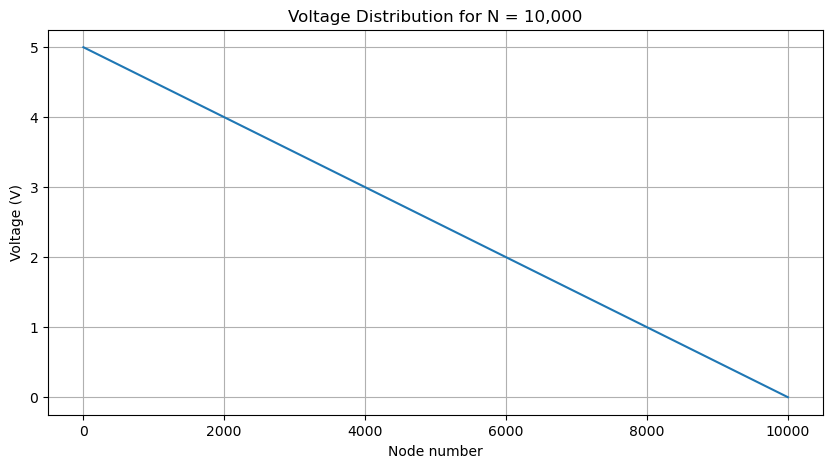

In [4]:
# Plot voltage for N = 10 000

nodes = np.arange(1, N+1)

plt.figure(figsize=(10,5))
plt.plot(nodes, V_bd)

plt.xlabel("Node number")
plt.ylabel("Voltage (V)")
plt.title("Voltage Distribution for N = 10,000")
plt.grid()

plt.show()

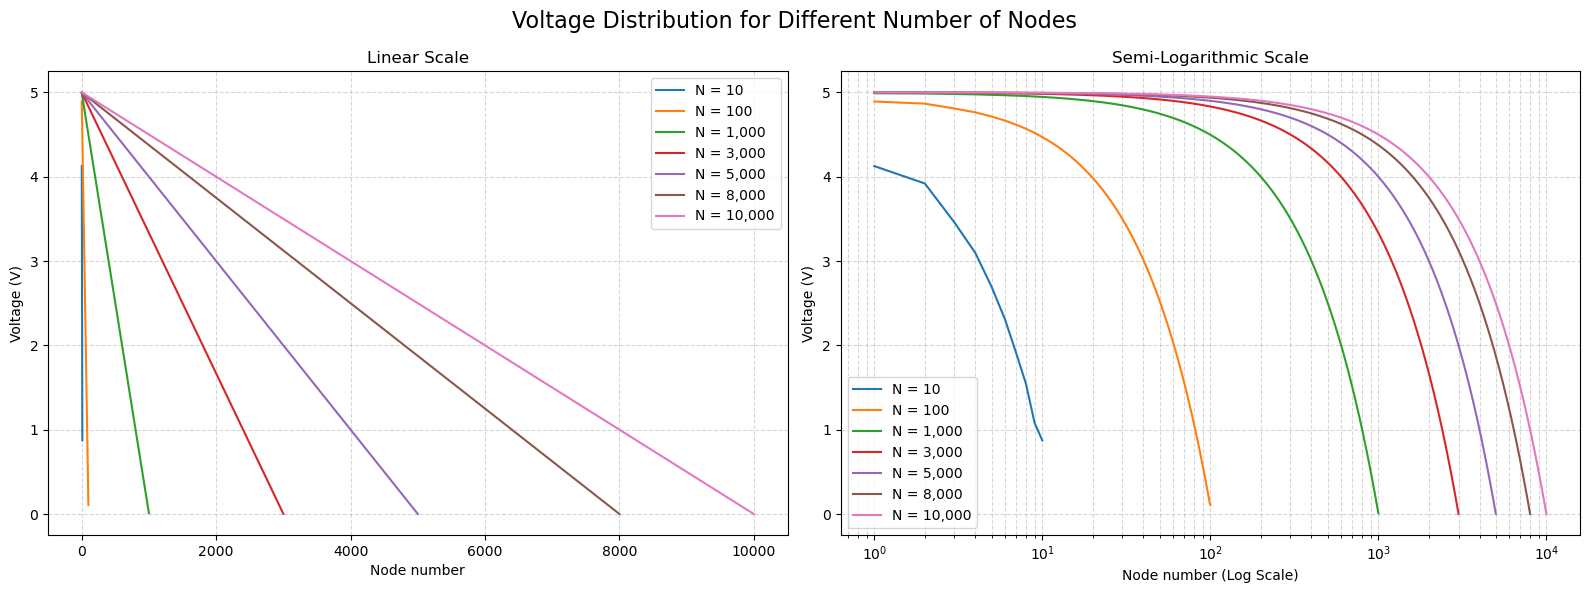

In [18]:
V = {} # Dictionary to store the voltage solutions for each value of N
N_counts = [10, 100, 1000, 3000, 5000, 8000, 10000] # List of N values 

# Solve the resistor ladder for different numbers of nodes
for N in N_counts:

    # Create a banded matrix with 2 lower and 2 upper diagonals
    A_bd = np.zeros((5, N))

    # Set the main diagonal: 3 at the endpoints and 4 at interior nodes
    A_bd[2, :] = 4
    A_bd[2, 0] = 3
    A_bd[2, N-1] = 3

    # Set the upper diagonals to -1
    A_bd[1, 1:] = -1
    A_bd[0, 2:] = -1

    # Set the lower diagonals to -1
    A_bd[3, :-1] = -1
    A_bd[4, :-2] = -1

    # Create the right-hand side vector
    w_bd = np.zeros(N)

    # Apply the 5 V boundary conditions to the first two nodes
    w_bd[0] = 5
    w_bd[1] = 5

    # Solve the banded system and store the voltage values
    V[N] = bd.banded(A_bd, w_bd, 2, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear Scale

# Plot the voltage distribution for each value of N
for N in N_counts:
    ax1.plot(
        np.arange(1, N + 1),
        V[N],
        label=f"N = {N:,}"
    )

ax1.set_xlabel("Node number")
ax1.set_ylabel("Voltage (V)")
ax1.set_title("Linear Scale")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# Semi-Logarithmic Scale

# Plot the voltage distribution for each value of N
for N in N_counts: ax2.semilogx(np.arange(1, N + 1), V[N], label=f"N = {N:,}")

ax2.set_xlabel("Node number (Log Scale)")
ax2.set_ylabel("Voltage (V)")
ax2.set_title("Semi-Logarithmic Scale")
ax2.legend()
ax2.grid(True, which="both", linestyle="--", alpha=0.5)

fig.suptitle("Voltage Distribution for Different Number of Nodes", fontsize=16)

plt.tight_layout()
plt.show()


#### Problem 1 code summary


This code constructs and solves the voltage equations for resistor networks with different numbers of nodes. A banded matrix representation is used for larger systems because it stores only the nonzero diagonals, making the computation more memory-efficient while maintaining the same matrix structure as the full system. The `bd.banded` function is then used to solve the resulting system of equations for each value of $N$. The calculated node voltages are plotted using both linear and semi-logarithmic scales to compare the voltage distribution as the number of nodes increases.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

ModuleNotFoundError: No module named 'samplePackage'

In [ ]:
sP.createZerosArray(4,5)